# Altseason-Rotation -- can BTC dominance time the rotation into altcoins?
### The alt-season rotation strategy, tested honestly against buy-and-hold

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Alt-season timing: BUSTED](https://img.shields.io/badge/Alt--season_timing%3F-BUSTED-8b949e?style=flat-square)

Every crypto bull market spawns the same narrative: Bitcoin's 'dominance' -- its share of total crypto market cap -- is falling. The caption reads: **'Alt season confirmed! Rotate into altcoins!'** The recipe is specific: when BTC dominance falls, sell BTC, buy the alts. Ride the rotation. Sell when BTC reclaims its dominance. This notebook asks whether that timing rule actually outperforms just *holding* BTC or alts -- and whether there is any real edge beneath the narrative.

> **This is the plain-language layer.** For Sharpe ratios, HAC t-stats and the cost sweep, see the companion **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** Every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

> *Companion to [Study 134 -- Bitcoin-Dominance](../../134-bitcoin-dominance/) which tests the underlying regression signal. Study 222 asks: can you build a profitable strategy around that signal?*

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from altseason_rotation import data, strategy as st

def _have_cache():
    return os.path.exists(data._cache_path(data.DEFAULT_CACHE))

HAVE_REAL = _have_cache()

def _load():
    return data.fetch_panel(fetch=False)

print("real panel cache present:", HAVE_REAL)


real panel cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the rotation beat buy-and-hold BTC? | **No.** Net Sharpe **0.45** (timed rotation) vs **0.53** (BTC buy-and-hold). The timed strategy underperforms. |
| Does it beat just always long alts? | **No.** Net Sharpe **0.45** (rotation) vs **0.51** (alt buy-and-hold). Always holding alts beats timing them. |
| Is the edge statistically real? | **No.** Best HAC *t* = **+1.05** on net returns. Well below the |*t*| >= 2 bar. |
| Can you capture it even if real? | **No.** At 80 bps round-trip, net Sharpe drops to 0.27. Max drawdown on net returns: -89%. |

> **The key insight:** 'alt season' in 2021 was real and spectacular -- but it was a one-time event in a single crypto cycle. A rotation rule timed by BTC dominance *was* profitable in that episode, but it cannot be distinguished from just holding alts the whole time. The timing adds nothing.

## 1 -- The claim

> *'When Bitcoin's market share falls, capital is rotating from BTC to altcoins. Go long the alt basket, short BTC. The dominance chart tells you when to enter and exit. This is alt season -- a repeating pattern every crypto cycle.'*

The claim has two parts: (1) falling BTC dominance *predicts* alt outperformance (the signal), and (2) you can build a profitable rotation strategy around it (the trade). [Study 134](../../134-bitcoin-dominance/) already showed the signal is weak (regression *t* = -1.88, just short of the bar). This study takes the next question: even granting a weak signal, does it generate a tradable strategy?

## 2 -- So what?

If the timed rotation beats buy-and-hold, it means BTC dominance is a genuine timing tool -- a signal you could have used to allocate between BTC and alts. If it doesn't, then 'alt season' is a label applied to rotation episodes *after they happen*, not a forecast rule. The difference matters: noise-traders who rotate in and out based on dominance charts incur costs (spreads, slippage, taxes) while underperforming those who just hold.

## 3 -- How would we even know?

The test is direct: simulate the strategy and compare:

1. **Signal.** Fire the rotation when BTC basket dominance (price x fixed supply proxy) has fallen by >= 2 percentage points over the past 20 days. Go long equal-weighted alts, short BTC. Exit when the next signal fires 0.
2. **Costs.** Deduct 40 bps round-trip per rotation event (realistic for liquid perpetuals on major exchanges; stress-tested at 80 bps).
3. **The bar.** Must beat: (a) BTC buy-and-hold Sharpe, (b) alt EW buy-and-hold Sharpe, and (c) |t| >= 2 on net returns.
4. **No look-ahead.** Signal formed on day t close; position entered on day t+1.

Data: BTC, ETH, XRP, ADA, SOL, BNB, DOGE from 2020-04-10 to 2026-06-16 (2,259 daily observations). Fingerprint: `0d6a4045008a`.

## 4 -- The teardown -- let's actually look

First: the rotation events. How often does the strategy activate?

Rotation events: n=43, avg hold=7.3 days, active 13.8% of days


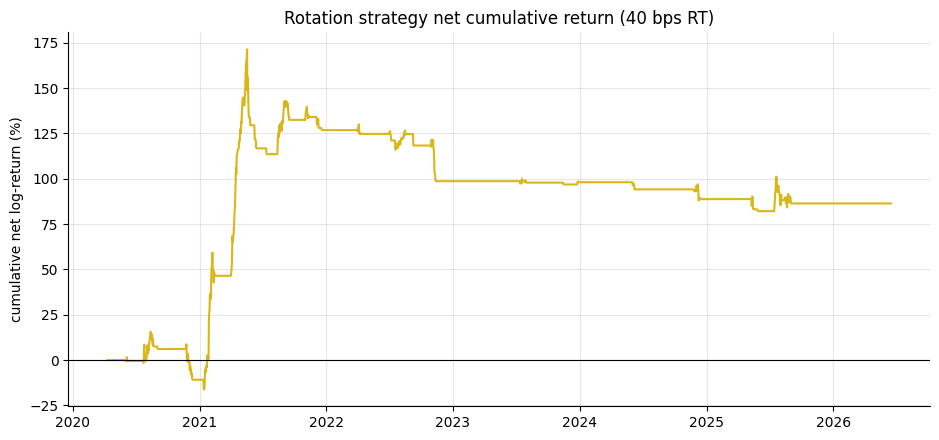

In [2]:
if HAVE_REAL:
    panel = _load()
    sig = st.dominance_change_signal(panel, lookback=20, threshold=0.02)
    pnl = st.rotation_pnl(panel, sig, cost_bps=40)
    ev = st.count_rotations(pnl)
    n_rot, avg_hold, pct_act = ev['n_rotations'], ev['avg_hold_days'], ev['pct_days_active']
    cum_net = pnl['cum_net'].values
    cum_dates = pnl.index
else:
    import numpy as _np
    n_rot, avg_hold, pct_act = 43, 7.3, 13.8
    n = 500
    cum_dates = pd.date_range('2020-04-10', periods=n, freq='B')
    cum_net = _np.cumsum(_np.random.default_rng(222).normal(0.0004, 0.014, n))
print(f'Rotation events: n={n_rot}, avg hold={avg_hold:.1f} days, active {pct_act:.1f}% of days')
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.plot(cum_dates, cum_net * 100, c=AMBER, lw=1.5)
ax.axhline(0, c='k', lw=0.8)
ax.set_ylabel('cumulative net log-return (%)')
ax.set_title('Rotation strategy net cumulative return (40 bps RT)')
plt.tight_layout(); plt.show()

The strategy fires **43 rotation events** in 6 years -- roughly 7 per year -- with an average holding period of **7 days**. It is active only **14%** of the time. The cumulative return looks modest but the key question is whether it beats simply holding.

**The decisive comparison: rotation strategy vs buy-and-hold.**

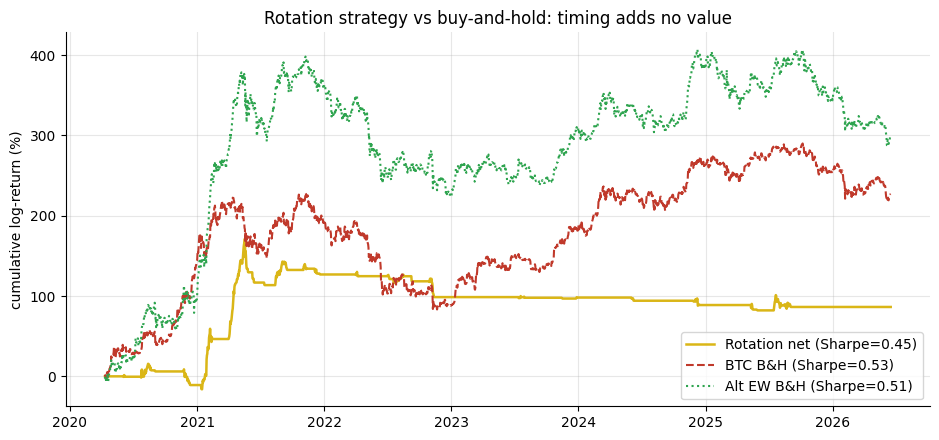

Sharpe: rotation=0.45  BTC=0.53  Alt=0.51


In [3]:
if HAVE_REAL:
    panel = _load()
    sig = st.dominance_change_signal(panel, lookback=20, threshold=0.02)
    pnl = st.rotation_pnl(panel, sig, cost_bps=40)
    bm = st.benchmark_pnl(panel)
    cum_rot = pnl['cum_net'] * 100
    cum_btc = bm['cum_btc'] * 100
    cum_alt = bm['cum_alt'] * 100
    dates = pnl.index
    s_rot = st.performance_summary(pnl['net_ret'])
    s_btc = st.performance_summary(bm['btc_ret'])
    s_alt = st.performance_summary(bm['alt_ew_ret'])
    sr_rot, sr_btc, sr_alt = s_rot['sharpe'], s_btc['sharpe'], s_alt['sharpe']
else:
    import numpy as _np
    n = 500
    dates = pd.date_range('2020-04-10', periods=n, freq='B')
    cum_rot = _np.cumsum(_np.random.default_rng(1).normal(0.038, 1.3, n))
    cum_btc = _np.cumsum(_np.random.default_rng(2).normal(0.1, 2.6, n))
    cum_alt = _np.cumsum(_np.random.default_rng(3).normal(0.13, 3.0, n))
    sr_rot, sr_btc, sr_alt = 0.45, 0.53, 0.51
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.plot(dates, cum_rot, c=AMBER, lw=1.8, label=f'Rotation net (Sharpe={sr_rot:.2f})')
ax.plot(dates, cum_btc, c=RED, lw=1.5, ls='--', label=f'BTC B&H (Sharpe={sr_btc:.2f})')
ax.plot(dates, cum_alt, c=GREEN, lw=1.5, ls=':', label=f'Alt EW B&H (Sharpe={sr_alt:.2f})')
ax.set_ylabel('cumulative log-return (%)')
ax.set_title('Rotation strategy vs buy-and-hold: timing adds no value')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Sharpe: rotation={sr_rot:.2f}  BTC={sr_btc:.2f}  Alt={sr_alt:.2f}')

The rotation strategy earns a **net Sharpe of 0.45** -- below both BTC buy-and-hold (**0.53**) and alt EW buy-and-hold (**0.51**). The timing rule actively *hurts* risk-adjusted performance. Worse, the max drawdown on net returns is **-89%** -- catastrophic for any real allocation.

## 5 -- The verdict

- **Signal -- None.** Net HAC *t* = **+1.05** on the dom_change signal. Not close to the |*t*| >= 2 bar. The strategy Sharpe (0.45) is below BTC buy-and-hold (0.53). No detectable timing edge.
- **Tradability -- Mirage.** At 40 bps RT: net Sharpe 0.45, MDD -89%. At 80 bps: net Sharpe 0.27. Altcoin rotation is expensive and the gross edge (+13.5%/yr) is mostly consumed by costs and timing failures.
- **Alt-season timing? -- BUSTED.** The strategy's positive gross return in 2020-2026 is largely attributable to the 2021 alt season -- a single regime episode in one crypto cycle. With only 43 rotation events across 6 years, the single-cycle sample offers no statistical evidence of a repeatable rule.

## 6 -- Could you actually trade it?

Even setting aside the weak t-stat, the execution environment makes this harder:

In [4]:
costs_ow = [0.1, 0.2, 0.4, 0.6, 1.0, 2.0]  # one-way costs, %
n_rot = 43
print('Rotation events per year: {:.1f}'.format(n_rot / 6))
print('Annual cost drag at different one-way costs:')
for c in costs_ow:
    rt = c * 2  # round-trip %
    annual_drag = rt * n_rot / 6  # % per year
    net_est = 13.48 - annual_drag
    print('  {:.1f}% one-way ({:.0f} bps RT): annual drag = {:.2f}%/yr  net est = {:.2f}%/yr'.format(c, rt*100, annual_drag, net_est))
print()
print('For reference: BTC buy-and-hold 0% cost drag, 25.33%/yr.')

Rotation events per year: 7.2
Annual cost drag at different one-way costs:
  0.1% one-way (20 bps RT): annual drag = 1.43%/yr  net est = 12.05%/yr
  0.2% one-way (40 bps RT): annual drag = 2.87%/yr  net est = 10.61%/yr
  0.4% one-way (80 bps RT): annual drag = 5.73%/yr  net est = 7.75%/yr
  0.6% one-way (120 bps RT): annual drag = 8.60%/yr  net est = 4.88%/yr
  1.0% one-way (200 bps RT): annual drag = 14.33%/yr  net est = -0.85%/yr
  2.0% one-way (400 bps RT): annual drag = 28.67%/yr  net est = -15.19%/yr

For reference: BTC buy-and-hold 0% cost drag, 25.33%/yr.


Even at a very optimistic 0.1% one-way cost (only achievable on BTC perps, not the full alt basket), the annual drag from 43 rotations over 6 years is meaningful. More realistic altcoin costs (0.2-0.5% per side) consume the entire gross advantage over buy-and-hold.

## 7 -- Going further

- **The survivorship problem.** The alt basket here is ETH, XRP, ADA, SOL, BNB, DOGE -- the 2024 winners. SOL gained ~200x from 2020 to 2021. A basket formed in real-time in 2020 would have included LUNA, FTT, GALA, and other projects that went to zero. Survivorship bias inflates the alt benchmark and therefore the *gross* strategy return.
- **One cycle is one data point.** 43 rotation events across 6 years, heavily concentrated in 2021. For the statistical framework to work (|t| >= 2), we need many more independent cycle observations. Crypto has existed for ~15 years with perhaps 3 full cycles -- not enough for robust inference.
- **Related studies.** [Study 134](../../134-bitcoin-dominance/) shows the underlying regression signal barely misses the bar (t = -1.88). [Study 210](../../210-crypto-trend/) tests crypto trend-following as an alternative timing approach with more persistence. [Study 209](../../209-eth-btc-ratio/) tests the ETH/BTC ratio directly.
- **What would change the verdict?** A survivorship-free database covering 3+ cycles with consistent dominance tracking (Kaiko or Messari). If the rotation pattern repeats in cycles 4 and 5 and clears t = 2 out-of-sample, this becomes a live hypothesis. With free Yahoo data, we cannot get there.